<a href="https://colab.research.google.com/github/Boaz5/lol-champ-ml/blob/main/CS489_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import top_k_accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# Data Processing and Collection




In [2]:
from google.colab import drive
import glob

drive.mount('/content/drive/', force_remount=True)

DATA_DIR = "/content/drive/MyDrive/DeepLearning/LOL"

csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))

dfs = []
for file in csv_files:
    try:
        df = pd.read_csv(file)
        df["source_file"] = os.path.basename(file)
        dfs.append(df)
        print(f"Loaded {os.path.basename(file)}: {df.shape}")
    except Exception as e:
        print(f"Failed to load {file}: {e}")

full_df = pd.concat(dfs, ignore_index=True)
print("Combined shape:", full_df.shape)
print(full_df.columns.tolist())

Mounted at /content/drive/
Loaded 2014_LoL_esports_match_data_from_OraclesElixir.csv: (11016, 166)
Loaded 2015_LoL_esports_match_data_from_OraclesElixir.csv: (21792, 166)
Loaded 2016_LoL_esports_match_data_from_OraclesElixir.csv: (50568, 166)
Loaded 2017_LoL_esports_match_data_from_OraclesElixir.csv: (68424, 166)
Loaded 2018_LoL_esports_match_data_from_OraclesElixir.csv: (80844, 166)
Loaded 2019_LoL_esports_match_data_from_OraclesElixir.csv: (97500, 166)
Loaded 2020_LoL_esports_match_data_from_OraclesElixir.csv: (117012, 166)
Loaded 2021_LoL_esports_match_data_from_OraclesElixir.csv: (148464, 166)


/tmp/ipykernel_85741/2292917733.py:13: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2022_LoL_esports_match_data_from_OraclesElixir.csv: (148980, 166)


/tmp/ipykernel_85741/2292917733.py:13: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2023_LoL_esports_match_data_from_OraclesElixir.csv: (133428, 166)


...

Loaded 2024_LoL_esports_match_data_from_OraclesElixir.csv: (122388, 166)


/tmp/ipykernel_85741/2292917733.py:13: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2025_LoL_esports_match_data_from_OraclesElixir.csv: (120636, 166)


/tmp/ipykernel_85741/2292917733.py:13: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2026_LoL_esports_match_data_from_OraclesElixir.csv: (46860, 166)
Combined shape: (1167912, 166)
['gameid', 'datacompleteness', 'url', 'league', 'year', 'split', 'playoffs', 'date', 'game', 'patch', 'participantid', 'side', 'position', 'playername', 'playerid', 'teamname', 'teamid', 'firstPick', 'champion', 'ban1', 'ban2', 'ban3', 'ban4', 'ban5', 'pick1', 'pick2', 'pick3', 'pick4', 'pick5', 'gamelength', 'result', 'kills', 'deaths', 'assists', 'teamkills', 'teamdeaths', 'doublekills', 'triplekills', 'quadrakills', 'pentakills', 'firstblood', 'firstbloodkill', 'firstbloodassist', 'firstbloodvictim', 'team kpm', 'ckpm', 'firstdragon', 'dragons', 'opp_dragons', 'elementaldrakes', 'opp_elementaldrakes', 'infernals', 'mountains', 'clouds', 'oceans', 'chemtechs', 'hextechs', 'dragons (type unknown)', 'elders', 'opp_elders', 'firstherald', 'heralds', 'opp_heralds', 'void_grubs', 'opp_void_grubs', 'firstbaron', 'barons', 'opp_barons', 'atakhans', 'opp_atakhans', 'firsttower', 'towers', '

Only keep matches that is complete/filtering incomplete datas

In [3]:
# Filter the DataFrame to only keep rows where 'datacompleteness' column has 'complete'
original_rows = len(full_df)
# display(full_df[full_df['gameid'] == '218-247'].iloc[:20])
full_df = full_df[full_df['datacompleteness'] == 'complete'].copy()

print(f"Row Count before filtering for completeness: {original_rows}")
print(f"Row Count after filtering for completeness: {len(full_df)}")


Row Count before filtering for completeness: 1167912
Row Count after filtering for completeness: 1034448


In [4]:

needed_cols = ['gameid', 'side', 'position', 'champion', 'patch', 'result']
df = full_df[needed_cols].copy()
df.dropna(subset=['champion'], inplace=True)
df.head()

# print(full_df.iloc[:20])

,gameid,side,position,champion,patch,result
0,TRLH3/33,Blue,top,Trundle,3.15,1
1,TRLH3/33,Blue,jng,Vi,3.15,1
2,TRLH3/33,Blue,mid,Orianna,3.15,1
3,TRLH3/33,Blue,bot,Jinx,3.15,1
4,TRLH3/33,Blue,sup,Annie,3.15,1


Cleaning up and Standardize data

In [5]:
df['position'] = df['position'].astype(str).str.lower().str.strip()
df['side'] = df['side'].astype(str).str.lower().str.strip()
df['champion'] = df['champion'].astype(str).str.strip()

possible_positions = ['top', 'jng', 'mid', 'bot', 'sup', 'jungle', 'adc', 'support']
# print(df["position"].value_counts())
# print(df.loc[~df['position'].isin(possible_positions)])
df = df[df['position'].isin(possible_positions)].copy()

role_map = {
    'jng': 'jungle',
    'bot': 'adc',
    'sup': 'support'
}

# Help Standardized the role names as jungle, adc, and support is more commonly recognize
df['position'] = df['position'].replace(role_map)
print(df['position'].value_counts())
# print(df['side'].value_counts())


position
top        172408
jungle     172408
mid        172408
adc        172408
support    172408
Name: count, dtype: int64


Only keep valid matches that have 10 players exactly (just in case a match isnt valid)

In [6]:
match_counts = df.groupby('gameid').size()
valid_matches = match_counts[match_counts == 10].index
df = df[df['gameid'].isin(valid_matches)].copy()

print("Rows:", len(df))
print("Unique matches:", df["gameid"].nunique())

Rows: 862040
Unique matches: 86204


Iterate to each player each game and extract info regarding the player's target_champion, their role, what patch the game is from, and result. Also store the list of other champions picked in the match

In [7]:
samples = []

for gameid, group in df.groupby("gameid"):
    group_rows = group.reset_index(drop=True)
    champs = group_rows["champion"].tolist()

    for i in range(len(group_rows)):
        row = group_rows.iloc[i]
        other_champs = champs[:i] + champs[i+1:]

        samples.append({
            "gameid": gameid,
            "role": row["position"],
            "side": row["side"],
            "target_champion": row["champion"],
            "patch": row["patch"],
            "result": row["result"],
            "other_champions": other_champs
        })

samples_df = pd.DataFrame(samples)
print(samples_df.shape)
samples_df.head()

(862040, 7)


,gameid,role,side,target_champion,patch,result,other_champions
0,2899-3157,top,blue,Ornn,8.01,1,"[Kha'Zix, Orianna, Ezreal, Tahm Kench, Maokai,..."
1,2899-3157,jungle,blue,Kha'Zix,8.01,1,"[Ornn, Orianna, Ezreal, Tahm Kench, Maokai, Ja..."
2,2899-3157,mid,blue,Orianna,8.01,1,"[Ornn, Kha'Zix, Ezreal, Tahm Kench, Maokai, Ja..."
3,2899-3157,adc,blue,Ezreal,8.01,1,"[Ornn, Kha'Zix, Orianna, Tahm Kench, Maokai, J..."
4,2899-3157,support,blue,Tahm Kench,8.01,1,"[Ornn, Kha'Zix, Orianna, Ezreal, Maokai, Jarva..."


# Feature Engineering

These cells calculate historical winrates per champion and per champion's role combination, which are added as important feature for the model

In [8]:
samples_df['temp_original_idx'] = samples_df.index

# Sort by patch, gameid, and original_index to ensure correct historical context
samples_df_sorted = samples_df.sort_values(by=['patch', 'gameid', 'temp_original_idx']).reset_index(drop=True)

# Calculate historical winrate using cumulative sum
# Group by champion, then apply expanding sum/count, and shift.

def calculate_cumulative_stats(group):
    group['wins_cum_sum'] = group['result'].cumsum()
    group['games_cum_count'] = (group.index - group.index[0]) + 1 # Equivalent to cumcount + 1
    group['prev_wins_cum_sum'] = group['wins_cum_sum'].shift(1).fillna(0)
    group['prev_games_cum_count'] = group['games_cum_count'].shift(1).fillna(0)
    return group

samples_df_sorted = samples_df_sorted.groupby('target_champion', group_keys=False).apply(calculate_cumulative_stats)

# Calculate historical winrate
samples_df_sorted['historical_winrate'] = np.where(
    samples_df_sorted['prev_games_cum_count'] > 0,
    samples_df_sorted['prev_wins_cum_sum'] / samples_df_sorted['prev_games_cum_count'],
    0.5 # Default to 0.5 (50%) for the first game of a champion or if no prior data
)

# Merge the new feature back to the original samples_df
# Ensure to drop the helper column 'temp_original_idx' and replace the old 'patch' if necessary.
samples_df = pd.merge(samples_df.drop(columns=['historical_winrate'] if 'historical_winrate' in samples_df.columns else []),
                      samples_df_sorted[['temp_original_idx', 'historical_winrate']],
                      on='temp_original_idx',
                      how='left').drop(columns='temp_original_idx')

print("Historical winrate feature added to samples_df.")
print(samples_df[['gameid', 'patch', 'target_champion', 'result', 'historical_winrate']].head())

/tmp/ipykernel_85741/2717915352.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samples_df_sorted = samples_df_sorted.groupby('target_champion', group_keys=False).apply(calculate_cumulative_stats)


Historical winrate feature added to samples_df.
      gameid  patch target_champion  result  historical_winrate
0  2899-3157   8.01            Ornn       1            0.008772
1  2899-3157   8.01         Kha'Zix       1            0.006547
2  2899-3157   8.01         Orianna       1            0.008542
3  2899-3157   8.01          Ezreal       1            0.008693
4  2899-3157   8.01      Tahm Kench       1            0.005979


Add Historical winrate by Role

In [9]:
# Store original index to merge back later, if samples_df was reset or re-created
samples_df['temp_original_idx_role'] = samples_df.index

# Sort by patch, gameid, role, and original_index to ensure correct 'historical' context
# for winrate per champion per role.
samples_df_sorted_role = samples_df.sort_values(by=['patch', 'gameid', 'role', 'temp_original_idx_role']).reset_index(drop=True)

# Calculate historical winrate using cumulative sum (expanding window) per champion-role combination
def calculate_cumulative_stats_role(group):
    group['wins_cum_sum_role'] = group['result'].cumsum()
    group['games_cum_count_role'] = (group.index - group.index[0]) + 1
    group['prev_wins_cum_sum_role'] = group['wins_cum_sum_role'].shift(1).fillna(0)
    group['prev_games_cum_count_role'] = group['games_cum_count_role'].shift(1).fillna(0)
    return group

samples_df_sorted_role = samples_df_sorted_role.groupby(['target_champion', 'role'], group_keys=False).apply(calculate_cumulative_stats_role)

# Calculate historical role winrate
samples_df_sorted_role['historical_role_winrate'] = np.where(
    samples_df_sorted_role['prev_games_cum_count_role'] > 0,
    samples_df_sorted_role['prev_wins_cum_sum_role'] / samples_df_sorted_role['prev_games_cum_count_role'],
    0.5 # Default to 0.5 (50%) for the first game of a champion in a role or if no prior data
)

# Merge the new feature back to the original samples_df
samples_df = pd.merge(samples_df.drop(columns=['historical_role_winrate'] if 'historical_role_winrate' in samples_df.columns else []), # drop if it exist already
                      samples_df_sorted_role[['temp_original_idx_role', 'historical_role_winrate']],
                      on='temp_original_idx_role',
                      how='left').drop(columns='temp_original_idx_role') # Drop the helper column

print("Historical role winrate feature added.")
print(samples_df[['gameid', 'patch', 'target_champion', 'role', 'result', 'historical_winrate', 'historical_role_winrate']].head())

/tmp/ipykernel_85741/4017303340.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samples_df_sorted_role = samples_df_sorted_role.groupby(['target_champion', 'role'], group_keys=False).apply(calculate_cumulative_stats_role)


Historical role winrate feature added.
      gameid  patch target_champion     role  result  historical_winrate  \
0  2899-3157   8.01            Ornn      top       1            0.008772   
1  2899-3157   8.01         Kha'Zix   jungle       1            0.006547   
2  2899-3157   8.01         Orianna      mid       1            0.008542   
3  2899-3157   8.01          Ezreal      adc       1            0.008693   
4  2899-3157   8.01      Tahm Kench  support       1            0.005979   

   historical_role_winrate  
0                 0.008696  
1                 0.006498  
2                 0.008523  
3                 0.007853  
4                 0.005110  


# Prep Inputs for NN

In [10]:
all_champions = sorted(df["champion"].unique().tolist())
champ_to_idx = {champ: i for i, champ in enumerate(all_champions)}
idx_to_champ = {i: champ for champ, i in champ_to_idx.items()}
num_champs = len(all_champions)

roles = sorted(df["position"].unique().tolist())
role_to_idx = {role: i for i, role in enumerate(roles)}

print("Number of champions:", num_champs)
print("Roles:", roles)

Number of champions: 172
Roles: ['adc', 'jungle', 'mid', 'support', 'top']


Build the inputs

In [11]:
picked_ids = np.array(
    [[champ_to_idx[ch] for ch in champ_list]
     for champ_list in samples_df["other_champions"]], dtype=np.int32)

def one_hot_role(role, role_to_idx):
    vec = np.zeros(len(role_to_idx), dtype=np.float32)
    vec[role_to_idx[role]] = 1.0
    return vec

role_features_nn = np.vstack([
    one_hot_role(role, role_to_idx)
    for role in samples_df["role"]
]).astype(np.float32)

side_features_nn = samples_df["side"].map({"blue": 0, "red": 1}).to_numpy(dtype=np.float32).reshape(-1, 1)

# New feature: historical winrate and historical_role_winrate combined
winrate_features_nn = np.hstack([samples_df["historical_winrate"].to_numpy(dtype=np.float32).reshape(-1, 1),
                                 samples_df["historical_role_winrate"].to_numpy(dtype=np.float32).reshape(-1, 1)])

y = samples_df["target_champion"].map(champ_to_idx).to_numpy(dtype=np.int32)

print("picked_ids shape:", picked_ids.shape)
print("role_features_nn shape:", role_features_nn.shape)
print("side_features_nn shape:", side_features_nn.shape)
print("winrate_features_nn shape:", winrate_features_nn.shape)
print("y shape:", y.shape)

picked_ids shape: (862040, 9)
role_features_nn shape: (862040, 5)
side_features_nn shape: (862040, 1)
winrate_features_nn shape: (862040, 2)
y shape: (862040,)


Splitting based on match ID

In [12]:
unique_matches = samples_df["gameid"].unique()

train_matches, temp_matches = train_test_split(unique_matches, test_size=0.30, random_state=42)
val_matches, test_matches = train_test_split(temp_matches, test_size=0.50, random_state=42)

train_mask = samples_df["gameid"].isin(train_matches).to_numpy()
val_mask = samples_df["gameid"].isin(val_matches).to_numpy()
test_mask = samples_df["gameid"].isin(test_matches).to_numpy()

picked_train = picked_ids[train_mask]
picked_val = picked_ids[val_mask]
picked_test = picked_ids[test_mask]

role_train = role_features_nn[train_mask]
role_val = role_features_nn[val_mask]
role_test = role_features_nn[test_mask]

side_train = side_features_nn[train_mask]
side_val = side_features_nn[val_mask]
side_test = side_features_nn[test_mask]

winrate_train = winrate_features_nn[train_mask]
winrate_val = winrate_features_nn[val_mask]
winrate_test = winrate_features_nn[test_mask]

y_train = y[train_mask]
y_val = y[val_mask]
y_test = y[test_mask]

print("Train shapes:", picked_train.shape, role_train.shape, side_train.shape, winrate_train.shape, y_train.shape)
print("Val shapes:", picked_val.shape, role_val.shape, side_val.shape, winrate_val.shape, y_val.shape)
print("Test shapes:", picked_test.shape, role_test.shape, side_test.shape, winrate_test.shape, y_test.shape)

Train shapes: (603420, 9) (603420, 5) (603420, 1) (603420, 2) (603420,)
Val shapes: (129310, 9) (129310, 5) (129310, 1) (129310, 2) (129310,)
Test shapes: (129310, 9) (129310, 5) (129310, 1) (129310, 2) (129310,)


In [13]:
def one_hot_labels(y, num_classes):
    y_onehot = np.zeros((len(y), num_classes), dtype=np.float32)
    y_onehot[np.arange(len(y)), y] = 1.0
    return y_onehot

def softmax(Z):
    shift_Z = Z - np.max(Z, axis=1, keepdims=True)

    exp_Z = np.exp(shift_Z)
    summation = np.sum(exp_Z, axis=1, keepdims=True)
    return exp_Z / summation

def compute_class_weights(y, num_classes):
    counts = np.bincount(y, minlength=num_classes)
    total = len(y)
    weights = total / (num_classes * np.maximum(counts, 1))
    return weights.astype(np.float32)

def weighted_cross_entropy_loss(probs, y_true, class_weights):
    n = len(y_true)
    correct_probs = probs[np.arange(n), y_true]
    weights = class_weights[y_true]
    return -np.mean(weights * np.log(correct_probs + 1e-12))

def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return np.where(Z > 0, 1, 0)


In [14]:
def init_adam_state(param):
    return {
        "m": np.zeros_like(param, dtype=np.float32),
        "v": np.zeros_like(param, dtype=np.float32)
    }

def adam_update(param, grad, state, t, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
    state["m"] = beta1 * state["m"] + (1 - beta1) * grad
    state["v"] = beta2 * state["v"] + (1 - beta2) * (grad ** 2)

    m_hat = state["m"] / (1 - beta1 ** t)
    v_hat = state["v"] / (1 - beta2 ** t)

    param -= (lr * m_hat / (np.sqrt(v_hat) + eps))
    return param

In [15]:
def init_embedding(num_champs, num_roles, embed_dim=16, hidden_dim_1=64, hidden_dim_2=64, seed=42):
    np.random.seed(seed)

    E = np.random.randn(num_champs, embed_dim).astype(np.float32) * 0.01

    # input dimensions includes embed_dim, num_roles (one-hot), side (1), AND historical_winrate (2)
    input_dim = embed_dim + num_roles + 1 + winrate_train.shape[1] # used shape[1] for flexible winrate features

    # First Hidden Layer
    W1 = np.random.randn(input_dim, hidden_dim_1).astype(np.float32) * np.sqrt(2.0 / input_dim)
    b1 = np.zeros((1, hidden_dim_1), dtype=np.float32)

    # Second Hidden Layer
    W2 = np.random.randn(hidden_dim_1, hidden_dim_2).astype(np.float32) * np.sqrt(2.0 / hidden_dim_1)
    b2 = np.zeros((1, hidden_dim_2), dtype=np.float32)

    # Output Layer
    W3 = np.random.randn(hidden_dim_2, num_champs).astype(np.float32) * np.sqrt(2.0 / hidden_dim_2)
    b3 = np.zeros((1, num_champs), dtype=np.float32)

    params = {
        "E": E,
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2,
        "W3": W3,
        "b3": b3
    }

    adam_states = {name: init_adam_state(param) for name, param in params.items()}
    return params, adam_states

In [16]:
def forward_pass(picked_ids_batch, role_batch, side_batch, winrate_batch, params):
    E = params["E"]
    W1 = params["W1"]
    b1 = params["b1"]
    W2 = params["W2"]
    b2 = params["b2"]
    W3 = params["W3"]
    b3 = params["b3"]

    embedded = E[picked_ids_batch]
    draft_embed = embedded.mean(axis=1)

    # Concatenate all input features
    X_input = np.hstack([draft_embed, role_batch, side_batch, winrate_batch])

    # First Hidden Layer
    z1 = X_input @ W1 + b1
    h1 = relu(z1)

    # Second Hidden Layer
    z2 = h1 @ W2 + b2
    h2 = relu(z2)

    # Output Layer
    logits = h2 @ W3 + b3
    probs = softmax(logits)

    cache = {
        "embedded": embedded,
        "draft_embed": draft_embed,
        "X_input": X_input,
        "z1": z1,
        "h1": h1,
        "z2": z2,
        "h2": h2,
        "logits": logits,
        "probs": probs
    }

    return probs, cache

In [17]:
def backward_pass(picked_ids_batch, role_batch, side_batch, winrate_batch, y_batch, class_weights, params, cache):
    E = params["E"]
    W1 = params["W1"]
    W2 = params["W2"]
    W3 = params["W3"]

    X_input = cache["X_input"]
    z1 = cache["z1"]
    h1 = cache["h1"]
    z2 = cache["z2"]
    h2 = cache["h2"]
    probs = cache["probs"]

    batch_size = len(y_batch)
    num_classes = probs.shape[1]
    num_picks = picked_ids_batch.shape[1]

    y_onehot = one_hot_labels(y_batch, num_classes)
    sample_weights = class_weights[y_batch].reshape(-1, 1)

    # Output layer
    dlogits = (probs - y_onehot) * sample_weights
    dlogits /= batch_size

    dW3 = h2.T @ dlogits
    db3 = np.sum(dlogits, axis=0, keepdims=True)

    # Second Hidden Layer
    dh2 = dlogits @ W3.T
    dz2 = dh2 * relu_derivative(z2)

    dW2 = h1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    # First Hidden Layer
    dh1 = dz2 @ W2.T
    dz1 = dh1 * relu_derivative(z1)

    dW1 = X_input.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    dX_input = dz1 @ W1.T

    embed_dim = E.shape[1]
    # Extract gradient for draft_embed
    ddraft_embed = dX_input[:, :embed_dim]

    # distribute gradient back to the individual champion embeddings
    dembedded = np.repeat(ddraft_embed[:, np.newaxis, :] / num_picks, num_picks, axis=1)

    dE = np.zeros_like(E, dtype=np.float32)
    np.add.at(dE, picked_ids_batch, dembedded)

    grads = {
        "E": dE,
        "W1": dW1,
        "b1": db1,
        "W2": dW2,
        "b2": db2,
        "W3": dW3,
        "b3": db3
    }

    return grads

In [18]:
def predict_probability_embedding(picked_ids_arr, role_arr, side_arr, winrate_arr, params):
    probs, _ = forward_pass(picked_ids_arr, role_arr, side_arr, winrate_arr, params)
    return probs

def predict_embedding(picked_ids_arr, role_arr, side_arr, winrate_arr, params):
    probs = predict_probability_embedding(picked_ids_arr, role_arr, side_arr, winrate_arr, params)
    return np.argmax(probs, axis=1)

In [19]:
def train_model(
    picked_train, role_train, side_train, winrate_train, y_train,
    picked_val, role_val, side_val, winrate_val, y_val,
    num_champs, num_roles,
    embed_dim,
    hidden_dim_1,
    hidden_dim_2,
    learning_rate,
    epochs=20,
    batch_size=32,
    use_class_weights=True,
    seed=42
):
    params, adam_states = init_embedding(
        num_champs=num_champs,
        num_roles=num_roles,
        embed_dim=embed_dim,
        hidden_dim_1=hidden_dim_1,
        hidden_dim_2=hidden_dim_2,
        seed=seed
    )

    class_weights = (
        compute_class_weights(y_train, num_champs)
        if use_class_weights
        else np.ones(num_champs, dtype=np.float32)
    )

    n_samples = len(y_train)
    t = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_top1": [],
        "val_macro_f1": [],
        "val_top3": [],
        "val_top5": []
    }

    for epoch in range(epochs):
        indices = np.random.permutation(n_samples)

        picked_train_shuf = picked_train[indices]
        role_train_shuf = role_train[indices]
        side_train_shuf = side_train[indices]
        winrate_train_shuf = winrate_train[indices]
        y_train_shuf = y_train[indices]

        for start in range(0, n_samples, batch_size):
            end = start + batch_size

            picked_batch = picked_train_shuf[start:end]
            role_batch = role_train_shuf[start:end]
            side_batch = side_train_shuf[start:end]
            winrate_batch = winrate_train_shuf[start:end]
            y_batch = y_train_shuf[start:end]

            probs, cache = forward_pass(
                picked_batch, role_batch, side_batch, winrate_batch, params
            )

            grads = backward_pass(
                picked_batch, role_batch, side_batch, winrate_batch, y_batch,
                class_weights, params, cache
            )

            t += 1
            for name in params:
                params[name] = adam_update(
                    params[name], grads[name], adam_states[name], t,
                    lr=learning_rate
                )

        train_probs = predict_probability_embedding(picked_train, role_train, side_train, winrate_train, params)
        val_probs = predict_probability_embedding(picked_val, role_val, side_val, winrate_val, params)

        train_loss = weighted_cross_entropy_loss(train_probs, y_train, class_weights)
        val_loss = weighted_cross_entropy_loss(val_probs, y_val, class_weights)

        val_pred = np.argmax(val_probs, axis=1)
        val_top1 = np.mean(val_pred == y_val)
        val_macro_f1 = f1_score(y_val, val_pred, average="macro")
        val_top3 = top_k_accuracy_score(y_val, val_probs, k=3, labels=np.arange(num_champs))
        val_top5 = top_k_accuracy_score(y_val, val_probs, k=5, labels=np.arange(num_champs))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_top1"].append(val_top1)
        history["val_macro_f1"].append(val_macro_f1)
        history["val_top3"].append(val_top3)
        history["val_top5"].append(val_top5)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Top1: {val_top1:.4f} | "
            f"Val Top3: {val_top3:.4f} | "
            f"Val Top5: {val_top5:.4f} | "
            f"Val Macro F1: {val_macro_f1:.4f}"
        )

    return params, history

Start training

In [20]:
params, history = train_model(
    picked_train, role_train, side_train, winrate_train, y_train,
    picked_val, role_val, side_val, winrate_val, y_val,
    num_champs=num_champs,
    num_roles=len(role_to_idx),
    embed_dim=16,
    hidden_dim_1=64,
    hidden_dim_2=128,
    learning_rate=0.001,
    epochs=20,
    batch_size=32,
    use_class_weights=True,
    seed=42
)

Epoch 1/20 | Train Loss: 3.2338 | Val Loss: 3.2432 | Val Top1: 0.1403 | Val Top3: 0.3334 | Val Top5: 0.4747 | Val Macro F1: 0.0981
Epoch 2/20 | Train Loss: 2.5864 | Val Loss: 2.6420 | Val Top1: 0.2424 | Val Top3: 0.5390 | Val Top5: 0.6967 | Val Macro F1: 0.1978
Epoch 3/20 | Train Loss: 2.4120 | Val Loss: 2.4802 | Val Top1: 0.2828 | Val Top3: 0.5864 | Val Top5: 0.7351 | Val Macro F1: 0.2245
Epoch 4/20 | Train Loss: 2.2488 | Val Loss: 2.3272 | Val Top1: 0.3172 | Val Top3: 0.6224 | Val Top5: 0.7664 | Val Macro F1: 0.2663
Epoch 5/20 | Train Loss: 2.3194 | Val Loss: 2.4243 | Val Top1: 0.3033 | Val Top3: 0.5950 | Val Top5: 0.7342 | Val Macro F1: 0.2421
Epoch 6/20 | Train Loss: 2.0579 | Val Loss: 2.1571 | Val Top1: 0.3734 | Val Top3: 0.6845 | Val Top5: 0.8088 | Val Macro F1: 0.3080
Epoch 7/20 | Train Loss: 1.9702 | Val Loss: 2.0911 | Val Top1: 0.3915 | Val Top3: 0.7122 | Val Top5: 0.8341 | Val Macro F1: 0.3278
Epoch 8/20 | Train Loss: 1.8713 | Val Loss: 1.9875 | Val Top1: 0.4342 | Val Top3: 0

In [21]:
val_probs = predict_probability_embedding(picked_val, role_val, side_val, winrate_val, params)
val_pred = np.argmax(val_probs, axis=1)

val_top1 = np.mean(val_pred == y_val)
val_macro_f1 = f1_score(y_val, val_pred, average="macro")
val_top3 = top_k_accuracy_score(y_val, val_probs, k=3, labels=np.arange(num_champs))
val_top5 = top_k_accuracy_score(y_val, val_probs, k=5, labels=np.arange(num_champs))

print("Validation Top-1 Accuracy:", val_top1)
print("Validation Top-3 Accuracy:", val_top3)
print("Validation Top-5 Accuracy:", val_top5)
print("Validation Macro F1:", val_macro_f1)

Validation Top-1 Accuracy: 0.5663599102930941
Validation Top-3 Accuracy: 0.846206789884773
Validation Top-5 Accuracy: 0.9197355192947181
Validation Macro F1: 0.46949635674948


In [22]:
test_probs = predict_probability_embedding(picked_test, role_test, side_test, winrate_test, params)
test_pred = np.argmax(test_probs, axis=1)

test_top1 = np.mean(test_pred == y_test)
test_macro_f1 = f1_score(y_test, test_pred, average="macro")
test_top3 = top_k_accuracy_score(y_test, test_probs, k=3, labels=np.arange(num_champs))
test_top5 = top_k_accuracy_score(y_test, test_probs, k=5, labels=np.arange(num_champs))

print("Test Top-1 Accuracy:", test_top1)
print("Test Top-3 Accuracy:", test_top3)
print("Test Top-5 Accuracy:", test_top5)
print("Test Macro F1:", test_macro_f1)


Test Top-1 Accuracy: 0.5647823060861495
Test Top-3 Accuracy: 0.8433763823370196
Test Top-5 Accuracy: 0.9186605830948883
Test Macro F1: 0.46837570451721944


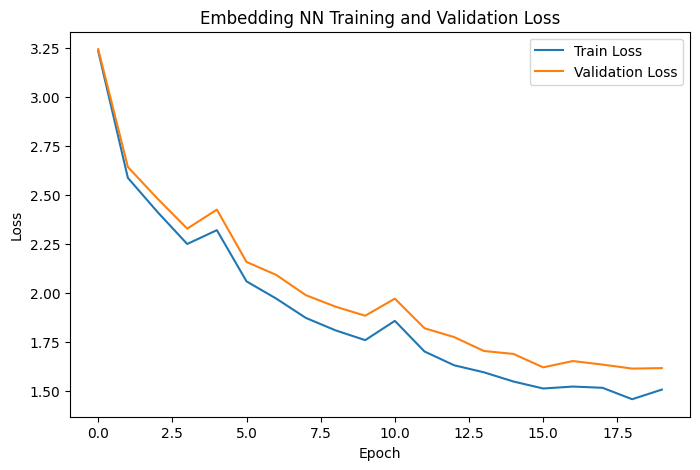

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Embedding NN Training and Validation Loss")
plt.legend()
plt.show()

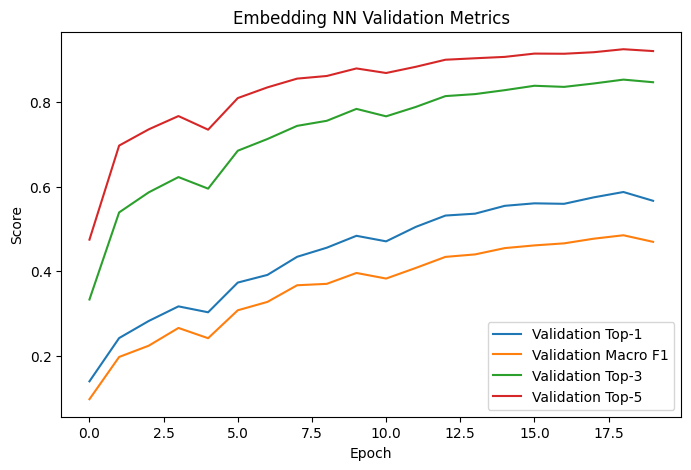

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(history["val_top1"], label="Validation Top-1")
plt.plot(history["val_macro_f1"], label="Validation Macro F1")
plt.plot(history["val_top3"], label="Validation Top-3")
plt.plot(history["val_top5"], label="Validation Top-5")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Embedding NN Validation Metrics")
plt.legend()
plt.show()

In [25]:
baseline_results = {
    "Top-1": 0.0928,
    "Macro F1": 0.0636,
    "Top-3": 0.2332,
    "Top-5": 0.3478
}

nn_results = {
    "Top-1": val_top1,
    "Macro F1": val_macro_f1,
    "Top-3": val_top3,
    "Top-5": val_top5
}

print("Baseline vs Embedding Neural Network (Validation)")
for metric in baseline_results:
    print(f"{metric}: baseline={baseline_results[metric]:.4f} | nn={nn_results[metric]:.4f}")

Baseline vs Embedding Neural Network (Validation)
Top-1: baseline=0.0928 | nn=0.5664
Macro F1: baseline=0.0636 | nn=0.4695
Top-3: baseline=0.2332 | nn=0.8462
Top-5: baseline=0.3478 | nn=0.9197


## Saving and Loading the Model


In [29]:
model_save_path = "saved_model.npz"

In [26]:

np.savez(model_save_path, **params)
print(f"Model parameters saved to {model_save_path}")

Model parameters saved to saved_model.npz


In [27]:

loaded_params = np.load(model_save_path, allow_pickle=True)
loaded_params_dict = {k: loaded_params[k] for k in loaded_params}
print("Model parameters loaded successfully.")

current_model_params = loaded_params_dict

Model parameters loaded successfully.


## Loading and doing a realistic Test


In [31]:
def make_prediction(
    sample_idx,
    picked_data, role_data, side_data, winrate_data, y_true,
    params,
    idx_to_champ, champ_to_idx, role_to_idx,
    original_samples_df, test_mask
):

    picked_sample = picked_data[sample_idx:sample_idx+1]
    role_sample = role_data[sample_idx:sample_idx+1]
    side_sample = side_data[sample_idx:sample_idx+1]
    winrate_sample = winrate_data[sample_idx:sample_idx+1]
    y_true_sample = y_true[sample_idx]

    # Make a prediction using the loaded model parameters
    probs = predict_probability_embedding(
        picked_sample, role_sample, side_sample, winrate_sample, params
    )

    # Get top-5 predictions
    top_5_indices = np.argsort(probs[0])[::-1][:5]
    top_5_champions = [idx_to_champ[i] for i in top_5_indices]
    top_5_probs = [probs[0, i] for i in top_5_indices]

    actual_champion_idx = y_true_sample
    actual_champion_name = idx_to_champ[actual_champion_idx]
    actual_role_idx = np.argmax(role_sample[0])
    actual_role_name = [role for role, idx in role_to_idx.items() if idx == actual_role_idx][0]
    actual_side = "Blue" if side_sample[0,0] == 0 else "Red"


    # Get the row from the original samples_df that corresponds to this test sample
    original_row_for_sample = original_samples_df[test_mask].iloc[sample_idx]
    gameid_for_sample = original_row_for_sample['gameid']
    target_champion_side_str = original_row_for_sample['side'] # 'blue' or 'red'

    # Filter the original samples_df for all players in this specific game
    full_game_champions = original_samples_df[original_samples_df['gameid'] == gameid_for_sample]

    ally_champions = []
    enemy_champions = []

    for i, player_row in full_game_champions.iterrows():
        if player_row['target_champion'] == actual_champion_name and player_row['role'] == actual_role_name and player_row['side'] == target_champion_side_str:
            continue
        if player_row['side'] == target_champion_side_str:
            ally_champions.append(f"{player_row['target_champion']} ({player_row['role']})")
        else:
            enemy_champions.append(f"{player_row['target_champion']} ({player_row['role']})")

    print(f"Prediction for Sample Index: {sample_idx}")
    print(f"------------------------------------------")
    print(f"Game ID: {gameid_for_sample}")
    print(f"Target Champion: {actual_champion_name} (Role: {actual_role_name}, Side: {actual_side})")
    print(f"Ally Team ({actual_side}): ", end="")
    for champ in ally_champions:
        print(champ, end=", ")
    print(f"\nEnemy Team ({'Red' if actual_side == 'Blue' else 'Blue'}): ")
    for champ in enemy_champions:
        print(champ, end=", ")

    print(f"\n\nTop 5 Predicted Champions:")
    for i, (champ, prob) in enumerate(zip(top_5_champions, top_5_probs)):
        print(f"{i+1}. {champ} (Probability: {prob:.4f})")

    if actual_champion_name in top_5_champions:
        print(f"\nActual champion '{actual_champion_name}' was found in the top 5 predictions.")
    else:
        print(f"\nActual champion '{actual_champion_name}' was NOT found in the top 5 predictions.")

# Choose a random sample from the test set for demonstration
np.random.seed(42)
random_test_sample_idx = np.random.randint(0, len(y_test))

make_prediction(
    random_test_sample_idx,
    picked_test, role_test, side_test, winrate_test, y_test,
    current_model_params,
    idx_to_champ, champ_to_idx, role_to_idx,
    samples_df, test_mask
)

Prediction for Sample Index: 121958
------------------------------------------
Game ID: TRLH1/1002520235
Target Champion: Jhin (Role: adc, Side: Red)
Ally Team (Red): Cho'Gath (top), Skarner (jungle), Orianna (mid), Morgana (support), 
Enemy Team (Blue): 
Shen (top), Sejuani (jungle), Ryze (mid), Caitlyn (adc), Lulu (support), 

Top 5 Predicted Champions:
1. Kalista (Probability: 0.2981)
2. Sivir (Probability: 0.2184)
3. Jhin (Probability: 0.1600)
4. Ezreal (Probability: 0.1054)
5. Kai'Sa (Probability: 0.0513)

Actual champion 'Jhin' was found in the top 5 predictions.
